In [42]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message="The behavior of DataFrame concatenation")

# Can DISC+ Predict Future Outcomes?
Perhaps the most important question for a statistic is its usefulness: does DISC+ predict outcomes that actually matter? In this case, it would be ideal if DISC+ demonstrates a knack for predicting things like BB%, K%, and OPS.

Normally, a predictive validity test would use year N to predict year N+1. Since only one year of data is available, I needed to change to a within-season holdout split instead: split the season chronologically, and compute DISC+/other companion stats for each respective half, then check whether they predict the later half's outcomes.

### Setup

In [43]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

from data_prep import load_pitches, clean_pitches
from dataset import build_dataset, get_ops

GAMES_DIR = "../input/gamedata"

MIN_PITCHES_HALF = 100

ALL_STATS = [
    "DISC+", "Swing%", "ZSwing%", "OSwing%", "Whiff%",
    "Contact%", "K%", "BB%", "Hard%", "BRL%",
]
OUTCOME_STATS = ["BB%", "K%", "OPS"]

In [44]:
pitches = clean_pitches(load_pitches(GAMES_DIR))

unique_dates = sorted(pitches['Date'].unique())
cutoff = unique_dates[len(unique_dates) // 2]

first_half = pitches[pitches['Date'] < cutoff]
second_half = pitches[pitches['Date'] >= cutoff]

print(f"Cutoff date: {cutoff}")
print(f"First half:  {first_half['Date'].nunique()} dates, {len(first_half)} pitches")
print(f"Second half: {second_half['Date'].nunique()} dates, {len(second_half)} pitches")

Cutoff date: 2026-06-28 00:00:00
First half:  29 dates, 72454 pitches
Second half: 31 dates, 77882 pitches


In [45]:
predictors = build_dataset(first_half, min_pitches=MIN_PITCHES_HALF)
predictors = predictors.rename(columns={c: f"{c}_H1" for c in ALL_STATS})

outcomes_kbb_ops = build_dataset(second_half, min_pitches=MIN_PITCHES_HALF)[['Batter', 'BB%', 'K%']]
outcomes_ops = get_ops(second_half)[['OPS']].reset_index()
outcomes = pd.merge(outcomes_kbb_ops, outcomes_ops, on='Batter')
outcomes = outcomes.rename(columns={c: f"{c}_H2" for c in OUTCOME_STATS})

data = pd.merge(predictors, outcomes, on='Batter')
print(f"Hitters qualifying in both halves: {len(data)}")
data.head()

Hitters qualifying in both halves: 182


,Batter,DISC+_H1,Swing%_H1,ZSwing%_H1,OSwing%_H1,Whiff%_H1,Contact%_H1,Hard%_H1,BRL%_H1,K%_H1,BB%_H1,BB%_H2,K%_H2,OPS_H2
0,Adam Kudronowicz,112.095672,0.394422,0.760563,0.250000,0.272727,0.727273,0.375000,0.041667,0.304348,0.173913,0.144578,0.253012,1.056
1,Adison Worthman,129.027397,0.366071,0.753247,0.163265,0.268293,0.731707,0.366667,0.066667,0.341463,0.195122,0.188406,0.333333,1.234
2,Aiden McClary,58.036532,0.438596,0.808824,0.281250,0.140000,0.860000,0.267442,0.000000,0.150943,0.150943,0.158730,0.095238,0.784
3,Alex Bemis,155.272489,0.340686,0.642857,0.182836,0.237410,0.762590,0.320755,0.037736,0.277778,0.319444,0.292683,0.304878,0.890
4,Amir Streeter,63.181927,0.489583,0.696970,0.380952,0.297872,0.702128,0.242424,0.000000,0.275362,0.086957,0.244444,0.244444,0.814


### Univariate predictive correlations

In [46]:
univariate = pd.DataFrame(index=ALL_STATS, columns=OUTCOME_STATS, dtype=float)

for stat in ALL_STATS:
    for outcome in OUTCOME_STATS:
        r, _ = pearsonr(data[f"{stat}_H1"], data[f"{outcome}_H2"])
        univariate.loc[stat, outcome] = r

univariate.round(3)

,BB%,K%,OPS
DISC+,0.397,0.028,0.049
Swing%,-0.343,-0.012,-0.019
ZSwing%,-0.252,0.005,0.012
OSwing%,-0.347,-0.013,-0.026
Whiff%,-0.135,0.466,0.001
Contact%,0.135,-0.466,-0.001
K%,0.038,0.508,-0.004
BB%,0.326,0.121,-0.057
Hard%,-0.165,-0.038,0.276
BRL%,-0.123,0.153,0.365


### Incremental predictive value

In [47]:
res = {}

for outcome in OUTCOME_STATS:
    y = data[f"{outcome}_H2"].values

    baseline_cols = [f"{s}_H1" for s in ALL_STATS if s != 'DISC+']
    aug_cols = baseline_cols + ['DISC+_H1']

    X_base = data[baseline_cols].values
    X_aug = data[aug_cols].values

    base_model = LinearRegression().fit(X_base, y)
    aug_model = LinearRegression().fit(X_aug, y)

    r2_base = base_model.score(X_base, y)
    r2_aug = aug_model.score(X_aug, y)

    residuals = y - base_model.predict(X_base)
    partial_r, _ = pearsonr(data['DISC+_H1'].values, residuals)

    res[outcome] = {
        'baseline_R2' : r2_base,
        'augmented_R2' : r2_aug,
        'incremental_R2' : r2_aug - r2_base,
        'DISC+_partial_error' : partial_r
    }

incremental = pd.DataFrame(res).T
incremental.round(3)

,baseline_R2,augmented_R2,incremental_R2,DISC+_partial_error
BB%,0.188,0.228,0.040,0.129
K%,0.307,0.310,0.003,0.038
OPS,0.179,0.180,0.000,0.014


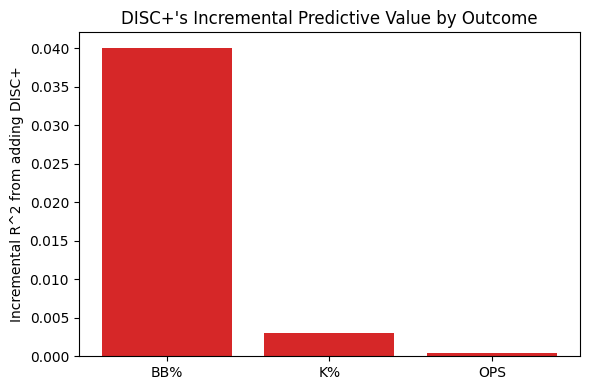

In [48]:
plt.figure(figsize=(6, 4))
plt.bar(incremental.index, incremental['incremental_R2'], color='#d62728')
plt.axhline(0, color='black', linewidth=0.0)
plt.ylabel("Incremental R^2 from adding DISC+")
plt.title("DISC+'s Incremental Predictive Value by Outcome")
plt.tight_layout()
plt.show()

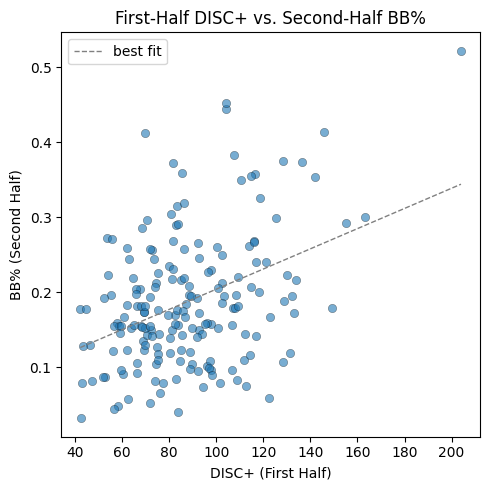

In [50]:
plt.figure(figsize=(5, 5))
plt.scatter(data["DISC+_H1"], data["BB%_H2"], alpha=0.6, edgecolor="k", linewidth=0.3)

z = np.polyfit(data["DISC+_H1"], data["BB%_H2"], 1)
xs = np.linspace(data["DISC+_H1"].min(), data["DISC+_H1"].max(), 100)
plt.plot(xs, np.polyval(z, xs), color="gray", linestyle="--", linewidth=1, label="best fit")

plt.xlabel("DISC+ (First Half)")
plt.ylabel("BB% (Second Half)")
plt.title("First-Half DISC+ vs. Second-Half BB%")
plt.legend()
plt.tight_layout()
plt.show()

### Takeaways

- DISC+ is the single best univariate predictor of future BB% in the entire table at 0.391. It is ahead of every companion stat, including BB% itself. For K% and OPS, though, DISC+ is essentially inert, sporting a value of 0.034 and 0.030, respectively.

DISC+, then, is not a general-purpose predictor of hitting outcomes. It has little to no relationship with future strikeout rate or power production. But, it does predict future walk rate better than any single stat in the table, including BB% itself. This is a narrower result than measuring plate discipline as a whole, but it is a real, specific, and defensible result with potential uses by baseball teams.